In [1]:
# %%
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.0 MB/s eta 0:00:00


In [2]:
# %%
import os
import glob
import cv2
import torch
import matplotlib.pyplot as plt
from ultralytics import YOLO

print("Libraries imported successfully.")
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    DEVICE = 0
else:
    print("GPU is not enabled. Training will be slow.")
    DEVICE = "cpu"

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Libraries imported successfully.
CUDA Available: True
GPU: Tesla T4


In [3]:
# %%
# Dataset path

DATASET_PATH = "/kaggle/input/datasets/farzadnekouei/pothole-image-segmentation-dataset/Pothole_Segmentation_YOLOv8"

print("Dataset path exists:", os.path.exists(DATASET_PATH))

if os.path.exists(DATASET_PATH):
    print("Files inside dataset:")
    print(os.listdir(DATASET_PATH))
else:
    print("Dataset path is wrong. Check your Kaggle input path.")

Dataset path exists: True
Files inside dataset:
['README.dataset.txt', 'README.roboflow.txt', 'data.yaml', 'valid', 'sample_video.mp4', 'train']


In [4]:
# %%
# Check train and validation data

train_images = glob.glob(f"{DATASET_PATH}/train/images/*")
train_labels = glob.glob(f"{DATASET_PATH}/train/labels/*")

valid_images = glob.glob(f"{DATASET_PATH}/valid/images/*")
valid_labels = glob.glob(f"{DATASET_PATH}/valid/labels/*")

print("Training images:", len(train_images))
print("Training labels:", len(train_labels))
print("Validation images:", len(valid_images))
print("Validation labels:", len(valid_labels))

print("Sample training image:", train_images[:1])
print("Sample training label:", train_labels[:1])

Training images: 720
Training labels: 720
Validation images: 60
Validation labels: 60
Sample training image: ['/kaggle/input/datasets/farzadnekouei/pothole-image-segmentation-dataset/Pothole_Segmentation_YOLOv8/train/images/pic-139-_jpg.rf.87bfef6ce65eb5df5b6053523e6b4954.jpg']
Sample training label: ['/kaggle/input/datasets/farzadnekouei/pothole-image-segmentation-dataset/Pothole_Segmentation_YOLOv8/train/labels/pic-196-_jpg.rf.66a50a098577b349d7bee13dc9640c2e.txt']


In [5]:
# %%
# Create YOLO data.yaml file

YAML_PATH = "/kaggle/working/pothole_dataset.yaml"

yaml_content = f"""
path: {DATASET_PATH}
train: train/images
val: valid/images

names:
  0: pothole
"""

with open(YAML_PATH, "w") as f:
    f.write(yaml_content)

print("YAML file created:")
print(open(YAML_PATH).read())

YAML file created:

path: /kaggle/input/datasets/farzadnekouei/pothole-image-segmentation-dataset/Pothole_Segmentation_YOLOv8
train: train/images
val: valid/images

names:
  0: pothole



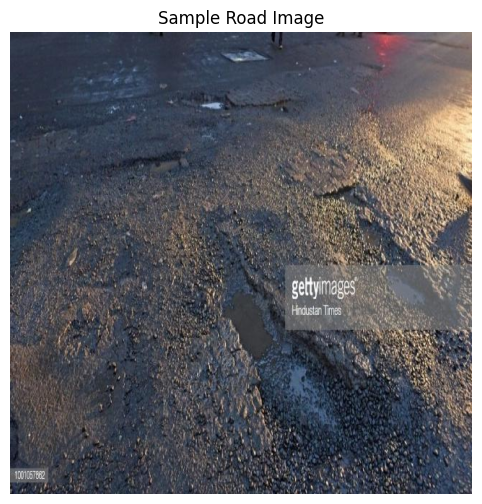

In [6]:
# %%
# Show one sample image

sample_image_path = train_images[0]

image = cv2.imread(sample_image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Sample Road Image")
plt.show()

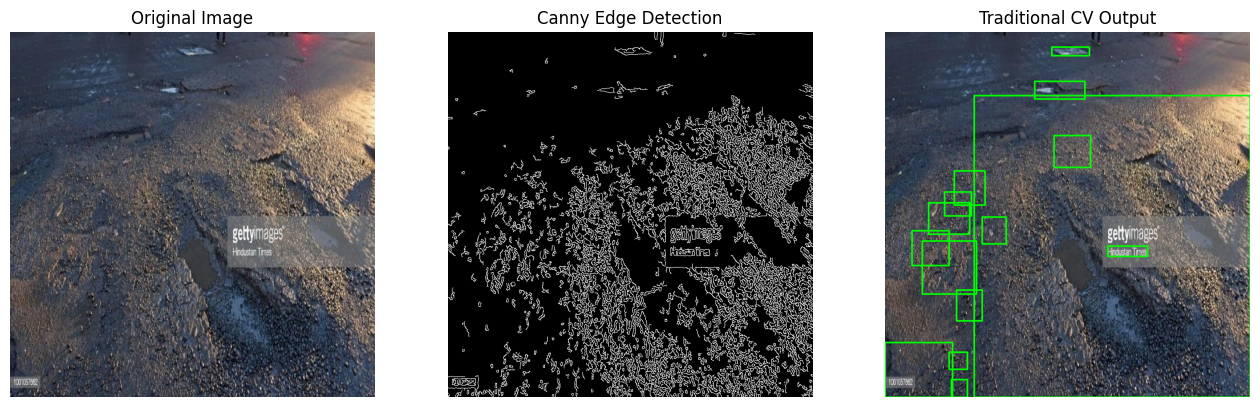

In [7]:
# %%
# Traditional Computer Vision on one image

def traditional_cv_pothole_detection(image_path):
    image = cv2.imread(image_path)

    if image is None:
        print("Image not found.")
        return

    original = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    edges = cv2.Canny(blur, 50, 150)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(
        closed,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    output = image.copy()

    for contour in contours:
        area = cv2.contourArea(contour)

        if area > 300:
            x, y, w, h = cv2.boundingRect(contour)
            cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 2)

    output = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(16, 8))

    plt.subplot(1, 3, 1)
    plt.imshow(original)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(edges, cmap="gray")
    plt.title("Canny Edge Detection")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(output)
    plt.title("Traditional CV Output")
    plt.axis("off")

    plt.show()


traditional_cv_pothole_detection(sample_image_path)

In [8]:
# %%
# Train YOLOv8 segmentation model

model = YOLO("yolov8n-seg.pt")

results = model.train(
    data=YAML_PATH,
    epochs=30,
    imgsz=640,
    batch=8,
    device=DEVICE,
    project="/kaggle/working/runs",
    name="pothole_segmentation_model"
)

print("Training completed.")

Ultralytics 8.4.50 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/pothole_dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=pothole_segmentation_model, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, over

In [9]:
# %%
# Evaluate trained model

best_model_path = "/kaggle/working/runs/pothole_segmentation_model/weights/best.pt"

trained_model = YOLO(best_model_path)

metrics = trained_model.val(
    data=YAML_PATH,
    imgsz=640,
    batch=8,
    device=DEVICE
)

print("Evaluation Results")
print("------------------")
print("Box mAP50:", metrics.box.map50)
print("Box mAP50-95:", metrics.box.map)
print("Mask mAP50:", metrics.seg.map50)
print("Mask mAP50-95:", metrics.seg.map)

Ultralytics 8.4.50 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,258,259 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 159.0±41.1 MB/s, size: 107.4 KB)
val: Scanning /kaggle/input/datasets/farzadnekouei/pothole-image-segmentation-dataset/Pothole_Segmentation_YOLOv8/valid/labels... 60 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60 573.9it/s 0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/farzadnekouei/pothole-image-segmentation-dataset/Pothole_Segmentation_YOLOv8/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 3.3it/s 2.4s
                   all         60        201       0.69      0.657      0.689      0.428      0.712      0.677      0.719       0.41
Speed: 3.5ms preprocess, 10.2ms inference, 0.0ms loss, 5.2ms postpr

In [10]:
# %%
# Predict on 5 validation images

test_images = valid_images[:5]

trained_model.predict(
    source=test_images,
    conf=0.25,
    save=True,
    project="/kaggle/working/runs",
    name="unseen_predictions"
)

print("Prediction completed.")


0: 640x640 3 potholes, 12.3ms
1: 640x640 15 potholes, 12.3ms
2: 640x640 1 pothole, 12.3ms
3: 640x640 2 potholes, 12.3ms
4: 640x640 3 potholes, 12.3ms
Speed: 2.0ms preprocess, 12.3ms inference, 3.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/runs/unseen_predictions
Prediction completed.


Predicted images found: 5


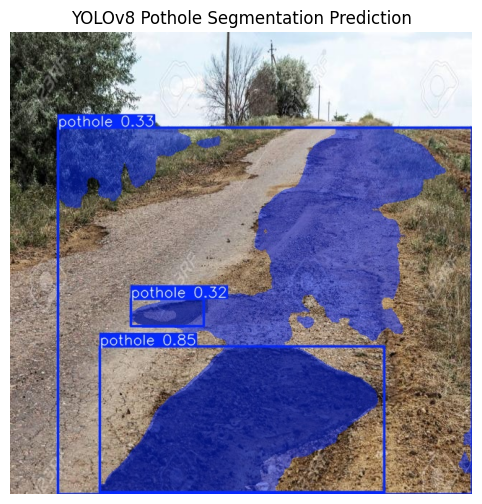

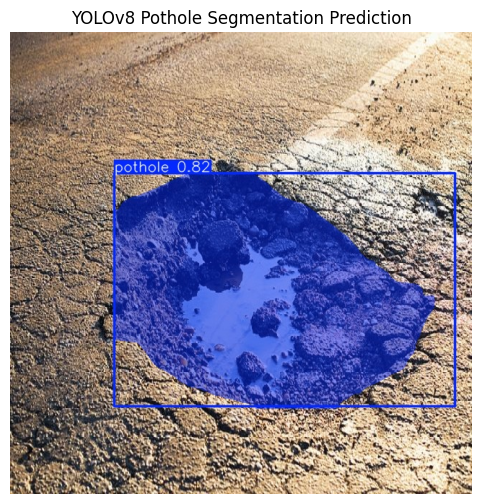

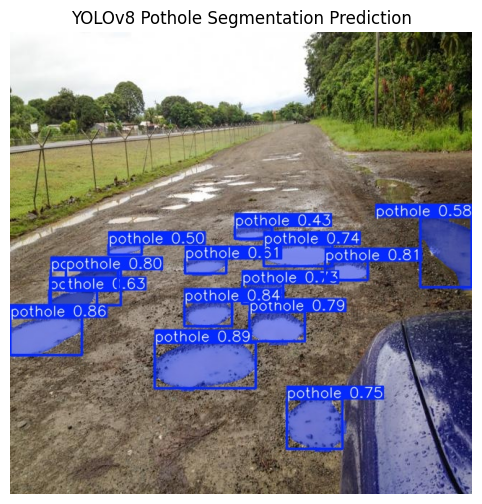

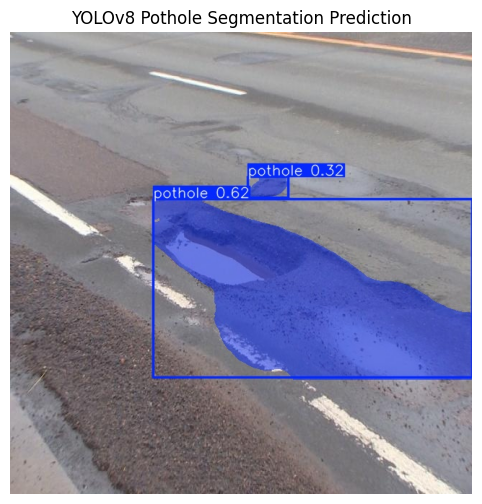

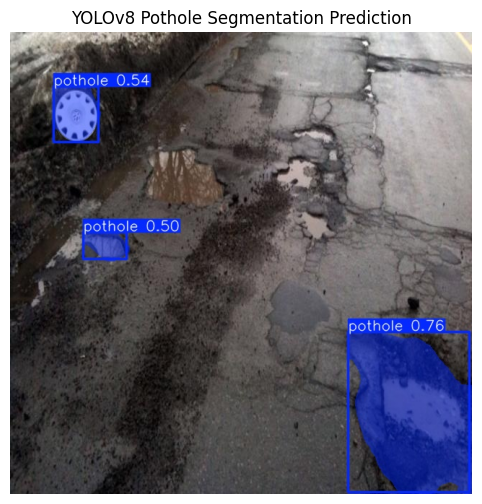

In [11]:
# %%
# Show prediction results

predicted_images = glob.glob("/kaggle/working/runs/unseen_predictions/*")

print("Predicted images found:", len(predicted_images))

for img_path in predicted_images[:5]:
    img = cv2.imread(img_path)

    if img is None:
        print("Could not read:", img_path)
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("YOLOv8 Pothole Segmentation Prediction")
    plt.show()

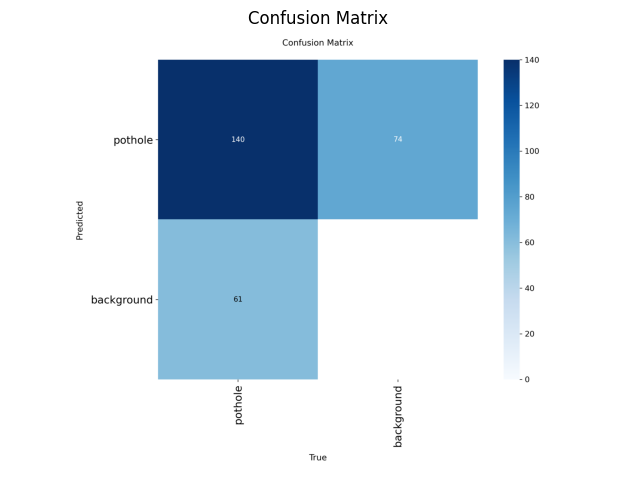

In [12]:
# %%
# Show confusion matrix

confusion_matrix_path = "/kaggle/working/runs/pothole_segmentation_model/confusion_matrix.png"

if os.path.exists(confusion_matrix_path):
    img = cv2.imread(confusion_matrix_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Confusion Matrix")
    plt.show()
else:
    print("Confusion matrix not found.")

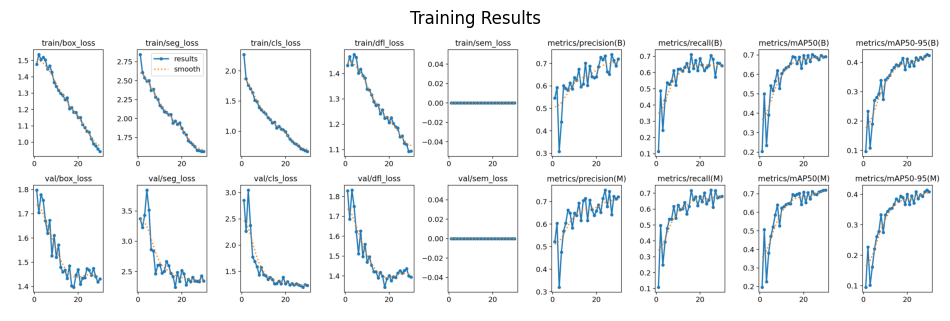

In [13]:
# %%
# Show training results graph

results_graph_path = "/kaggle/working/runs/pothole_segmentation_model/results.png"

if os.path.exists(results_graph_path):
    img = cv2.imread(results_graph_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Training Results")
    plt.show()
else:
    print("Training results graph not found.")

In [14]:
# %%
# Final model path

print("Best trained model saved at:")
print(best_model_path)

Best trained model saved at:
/kaggle/working/runs/pothole_segmentation_model/weights/best.pt


In [15]:
import shutil

source_path = "/kaggle/working/runs/pothole_segmentation_model/weights/best.pt"
download_path = "/kaggle/working/best.pt"

shutil.copy(source_path, download_path)

print("Model copied to:", download_path)

Model copied to: /kaggle/working/best.pt
